# Profiling de SIAF Ingresos

Este notebook perfila los archivos de `data/bronze/ingresos`. La idea es analizar estructura, volumen, campos clave y riesgos de calidad sobre el dataset de ingresos públicos antes de cualquier transformación adicional.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.style.use('default')
pd.set_option('display.max_columns', 100)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
INGRESOS_PATH = PROJECT_ROOT / 'data' / 'bronze' / 'ingresos'

KEY_COLUMNS = [
    'ANO_DOC', 'MES_DOC', 'NIVEL_GOBIERNO', 'NIVEL_GOBIERNO_NOMBRE',
    'DEPARTAMENTO_EJECUTORA', 'DEPARTAMENTO_EJECUTORA_NOMBRE', 'PROVINCIA_EJECUTORA',
    'PROVINCIA_EJECUTORA_NOMBRE', 'DISTRITO_EJECUTORA', 'DISTRITO_EJECUTORA_NOMBRE',
    'SEC_EJEC', 'PLIEGO', 'EJECUTORA', 'FUENTE_FINANCIAMIENTO', 'RUBRO',
    'GENERICA', 'SUBGENERICA', 'ESPECIFICA', 'ESPECIFICA_DET', 'TIPO_RECURSO',
    'RUBRO_NOMBRE', 'FUENTE_FINANCIAMIENTO_NOMBRE', 'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO'
]

data_files = sorted([path for path in INGRESOS_PATH.glob('*.csv') if path.name != 'Ingresos_Diccionario.csv'])
dictionary_file = INGRESOS_PATH / 'Ingresos_Diccionario.csv'

print(f'Total archivos de datos: {len(data_files)}')
print(f'Diccionario disponible: {dictionary_file.exists()}')

Total archivos de datos: 15
Diccionario disponible: True


## Carga y preparación

Los archivos de ingresos son voluminosos, así que se cargan solo columnas relevantes para el profiling. Además se agrega `source_file` para mantener trazabilidad del origen.

In [2]:
def read_ingresos_file(file_path: Path, key_columns: list[str]) -> pd.DataFrame:
    header = pd.read_csv(file_path, nrows=0, encoding='utf-8-sig', engine='python', on_bad_lines='skip')
    available_columns = [column.replace('﻿', '').strip() for column in header.columns]
    normalized_map = dict(zip(header.columns, available_columns))
    usecols = [original for original, normalized in normalized_map.items() if normalized in key_columns]

    frame = pd.read_csv(file_path, usecols=usecols, encoding='utf-8-sig', engine='python', on_bad_lines='skip')
    frame.columns = [column.replace('﻿', '').strip() for column in frame.columns]
    frame['source_file'] = file_path.name
    return frame

ingresos_frames = [read_ingresos_file(file_path, KEY_COLUMNS) for file_path in data_files]
ingresos_df = pd.concat(ingresos_frames, ignore_index=True)

for column in ['ANO_DOC', 'MES_DOC', 'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO']:
    ingresos_df[column] = pd.to_numeric(ingresos_df[column], errors='coerce')

for column in ['SEC_EJEC', 'PLIEGO', 'EJECUTORA', 'FUENTE_FINANCIAMIENTO', 'RUBRO', 'GENERICA', 'SUBGENERICA', 'ESPECIFICA', 'ESPECIFICA_DET', 'TIPO_RECURSO']:
    ingresos_df[column] = ingresos_df[column].astype('string')

dictionary_df = pd.read_csv(dictionary_file, encoding='utf-8-sig', low_memory=False) if dictionary_file.exists() else pd.DataFrame()

ingresos_df.shape

(125294, 26)

## Exploración inicial

Esta parte revisa el tamaño del dataset consolidado, la estructura de columnas, los tipos y una muestra inicial para entender el contenido antes de pasar al profiling descriptivo.

In [3]:
display(ingresos_df.head())
display(ingresos_df.dtypes.to_frame('dtype').T)
missing_overview = ingresos_df.isna().mean().sort_values(ascending=False).to_frame('missing_ratio')
missing_overview.head(10)

,ANO_DOC,MES_DOC,NIVEL_GOBIERNO,NIVEL_GOBIERNO_NOMBRE,PLIEGO,SEC_EJEC,EJECUTORA,DEPARTAMENTO_EJECUTORA,DEPARTAMENTO_EJECUTORA_NOMBRE,PROVINCIA_EJECUTORA,PROVINCIA_EJECUTORA_NOMBRE,DISTRITO_EJECUTORA,DISTRITO_EJECUTORA_NOMBRE,FUENTE_FINANCIAMIENTO,FUENTE_FINANCIAMIENTO_NOMBRE,RUBRO,RUBRO_NOMBRE,TIPO_RECURSO,GENERICA,SUBGENERICA,ESPECIFICA,ESPECIFICA_DET,MONTO_PIA,MONTO_PIM,MONTO_RECAUDADO,source_file
0,2012.0,1.0,R,GOBIERNOS REGIONALES,440.0,721.0,1.0,01,AMAZONAS,01,CHACHAPOYAS,01,CHACHAPOYAS,2.0,RECURSOS DIRECTAMENTE RECAUDADOS,9.0,RECURSOS DIRECTAMENTE RECAUDADOS,0,3.0,1.0,1.0,3.0,44789.0,44789.0,577.00,2012-Ingreso.csv
1,2012.0,1.0,R,GOBIERNOS REGIONALES,440.0,721.0,1.0,01,AMAZONAS,01,CHACHAPOYAS,01,CHACHAPOYAS,2.0,RECURSOS DIRECTAMENTE RECAUDADOS,9.0,RECURSOS DIRECTAMENTE RECAUDADOS,0,3.0,1.0,1.0,4.0,0.0,0.0,0.00,2012-Ingreso.csv
2,2012.0,1.0,R,GOBIERNOS REGIONALES,440.0,721.0,1.0,01,AMAZONAS,01,CHACHAPOYAS,01,CHACHAPOYAS,2.0,RECURSOS DIRECTAMENTE RECAUDADOS,9.0,RECURSOS DIRECTAMENTE RECAUDADOS,0,3.0,1.0,1.0,2.0,17500.0,17500.0,1230.00,2012-Ingreso.csv
3,2012.0,1.0,R,GOBIERNOS REGIONALES,440.0,721.0,1.0,01,AMAZONAS,01,CHACHAPOYAS,01,CHACHAPOYAS,2.0,RECURSOS DIRECTAMENTE RECAUDADOS,9.0,RECURSOS DIRECTAMENTE RECAUDADOS,0,3.0,2.0,1.0,1.0,0.0,0.0,0.00,2012-Ingreso.csv
4,2012.0,1.0,R,GOBIERNOS REGIONALES,440.0,721.0,1.0,01,AMAZONAS,01,CHACHAPOYAS,01,CHACHAPOYAS,2.0,RECURSOS DIRECTAMENTE RECAUDADOS,9.0,RECURSOS DIRECTAMENTE RECAUDADOS,0,3.0,2.0,1.0,99.0,31706.0,31706.0,5515.96,2012-Ingreso.csv


,ANO_DOC,MES_DOC,NIVEL_GOBIERNO,NIVEL_GOBIERNO_NOMBRE,PLIEGO,SEC_EJEC,EJECUTORA,DEPARTAMENTO_EJECUTORA,DEPARTAMENTO_EJECUTORA_NOMBRE,PROVINCIA_EJECUTORA,PROVINCIA_EJECUTORA_NOMBRE,DISTRITO_EJECUTORA,DISTRITO_EJECUTORA_NOMBRE,FUENTE_FINANCIAMIENTO,FUENTE_FINANCIAMIENTO_NOMBRE,RUBRO,RUBRO_NOMBRE,TIPO_RECURSO,GENERICA,SUBGENERICA,ESPECIFICA,ESPECIFICA_DET,MONTO_PIA,MONTO_PIM,MONTO_RECAUDADO,source_file
dtype,float64,float64,object,object,string[python],string[python],string[python],object,object,object,object,object,object,string[python],object,string[python],object,string[python],string[python],string[python],string[python],string[python],float64,float64,float64,object


,missing_ratio
SUBGENERICA,0.000040
MONTO_PIA,0.000040
FUENTE_FINANCIAMIENTO,0.000032
DISTRITO_EJECUTORA,0.000032
TIPO_RECURSO,0.000032
DISTRITO_EJECUTORA_NOMBRE,0.000032
ESPECIFICA,0.000032
PLIEGO,0.000032
DEPARTAMENTO_EJECUTORA_NOMBRE,0.000024
ESPECIFICA_DET,0.000024


In [4]:
if not dictionary_df.empty:
    display(dictionary_df.head())
else:
    print('No se encontró el diccionario de datos.')

,VARIABLE,TIPO_DATO,DESCRIPCION
0,ANO_DOC,Numérico,Año del documento en que se realizaron los rec...
1,MES_DOC,Numérico,Mes del documento en que se realizaron los rec...
2,NIVEL_GOBIERNO,Carácter,Carácter que identifica el Nivel de Gobierno: ...
3,NIVEL_GOBIERNO_NOMBRE,Carácter,"Descripción de Nivel de Gobierno: Nacional, Re..."
4,SECTOR,Carácter,Código de Sector al que pertenece la Entidad.


## Profiling descriptivo

Aquí se resumen patrones básicos del dataset: volumen por año, distribución por nivel de gobierno, montos principales y rubros más frecuentes. Esta parte te sirve para defender qué contiene la fuente y qué tipo de decisiones puede soportar.

,ANO_DOC,records
0,2012.0,7906
1,2013.0,15111
2,2014.0,7791
3,2015.0,7475
4,2016.0,7475
5,2017.0,7421
6,2018.0,7425
7,2019.0,7385
8,2020.0,7365
9,2021.0,7349


,NIVEL_GOBIERNO_NOMBRE,records
0,GOBIERNOS REGIONALES,125294


,ANO_DOC,MONTO_PIA,MONTO_PIM,MONTO_RECAUDADO
0,2012.0,194255983.0,1.106156e+09,1.133458e+09
1,2013.0,593482631.0,1.375646e+09,1.150899e+09
2,2014.0,236865553.0,4.059881e+08,4.067285e+08
3,2015.0,126746411.0,4.009354e+08,4.080740e+08
4,2016.0,132964328.0,4.669687e+08,4.698548e+08


,RUBRO_NOMBRE,records
0,RECURSOS DIRECTAMENTE RECAUDADOS,92680
1,"CANON Y SOBRECANON, REGALIAS, RENTA DE ADUANAS...",17222
2,DONACIONES Y TRANSFERENCIAS,10002
3,FONDO DE COMPENSACION REGIONAL - FONCOR,2913
4,RECURSOS POR OPERACIONES OFICIALES DE CREDITO,2467
5,CONTRIBUCIONES A FONDOS,6
6,None,2
7,REC,1
8,NaN,1


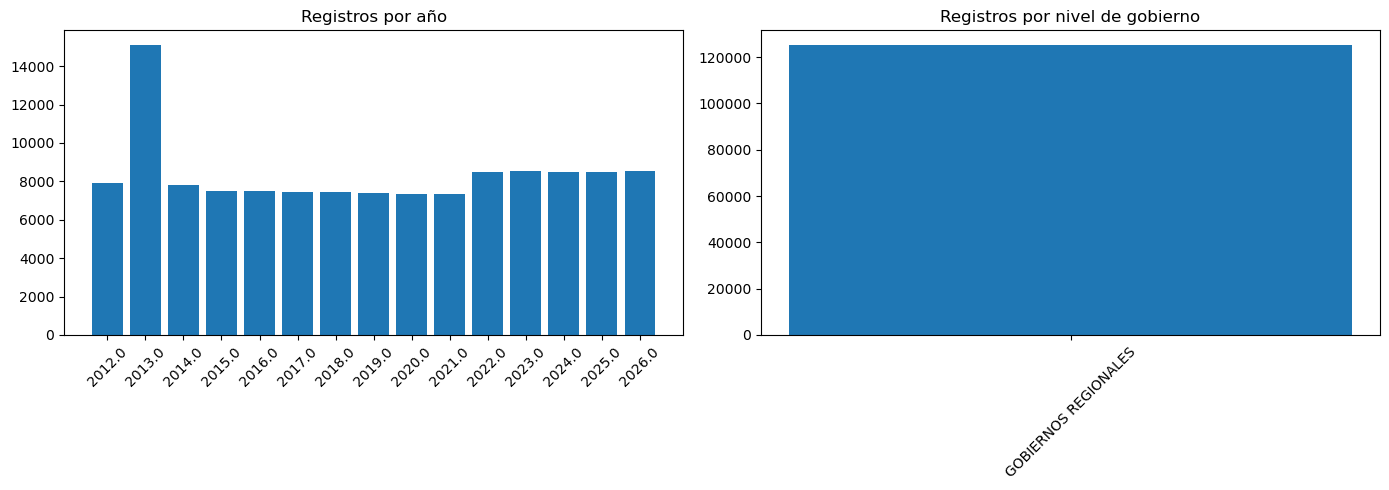

In [5]:
records_by_year = ingresos_df.groupby('ANO_DOC').size().reset_index(name='records').sort_values('ANO_DOC')
records_by_level = ingresos_df.groupby('NIVEL_GOBIERNO_NOMBRE').size().reset_index(name='records').sort_values('records', ascending=False)
amounts_by_year = ingresos_df.groupby('ANO_DOC')[['MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO']].sum(min_count=1).reset_index().sort_values('ANO_DOC')
top_rubros = ingresos_df['RUBRO_NOMBRE'].value_counts(dropna=False).head(10).reset_index()
top_rubros.columns = ['RUBRO_NOMBRE', 'records']

display(records_by_year)
display(records_by_level)
display(amounts_by_year.head())
display(top_rubros)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(records_by_year['ANO_DOC'].astype(str), records_by_year['records'])
axes[0].set_title('Registros por año')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(records_by_level['NIVEL_GOBIERNO_NOMBRE'].astype(str), records_by_level['records'])
axes[1].set_title('Registros por nivel de gobierno')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Calidad de datos - 8 dimensiones

**A partir de esta sección comienza formalmente la evaluación de calidad de datos para la fuente de ingresos.**

Las ocho dimensiones evaluadas son: completitud, unicidad, validez, consistencia, exactitud, integridad, actualidad y trazabilidad. Cada una se resume con una métrica concreta para facilitar la interpretación.

In [6]:
core_columns = ['ANO_DOC', 'MES_DOC', 'SEC_EJEC', 'MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO']
missing_core_ratio = ingresos_df[core_columns].isna().mean().mean()

candidate_key = ['ANO_DOC', 'MES_DOC', 'SEC_EJEC', 'GENERICA', 'SUBGENERICA', 'ESPECIFICA', 'ESPECIFICA_DET', 'FUENTE_FINANCIAMIENTO', 'RUBRO', 'TIPO_RECURSO']
duplicate_ratio = ingresos_df.duplicated(subset=candidate_key).mean()

valid_month_ratio = ingresos_df['MES_DOC'].between(1, 12).mean()
valid_year_ratio = ingresos_df['ANO_DOC'].between(2012, 2026).mean()
valid_level_ratio = ingresos_df['NIVEL_GOBIERNO'].isin(['N', 'R', 'L']).mean()
validez_ratio = np.nanmean([valid_month_ratio, valid_year_ratio, valid_level_ratio])

dept_consistency_ratio = ((ingresos_df['DEPARTAMENTO_EJECUTORA'].notna()) == (ingresos_df['DEPARTAMENTO_EJECUTORA_NOMBRE'].notna())).mean()
prov_consistency_ratio = ((ingresos_df['PROVINCIA_EJECUTORA'].notna()) == (ingresos_df['PROVINCIA_EJECUTORA_NOMBRE'].notna())).mean()
dist_consistency_ratio = ((ingresos_df['DISTRITO_EJECUTORA'].notna()) == (ingresos_df['DISTRITO_EJECUTORA_NOMBRE'].notna())).mean()
consistency_ratio = np.nanmean([dept_consistency_ratio, prov_consistency_ratio, dist_consistency_ratio])

non_negative_ratio = ((ingresos_df[['MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO']] >= 0) | ingresos_df[['MONTO_PIA', 'MONTO_PIM', 'MONTO_RECAUDADO']].isna()).all(axis=1).mean()

integrity_ratio = ingresos_df[['SEC_EJEC', 'PLIEGO', 'EJECUTORA']].notna().all(axis=1).mean()

expected_years = set(range(2012, 2027))
observed_years = set(ingresos_df['ANO_DOC'].dropna().astype(int).unique())
actualidad_ratio = len(observed_years & expected_years) / len(expected_years)

traceability_ratio = ingresos_df['source_file'].notna().mean()

quality_summary = pd.DataFrame([
    {'dimension': 'Completitud', 'metric': '1 - promedio de nulos en columnas clave', 'score': round(1 - missing_core_ratio, 4)},
    {'dimension': 'Unicidad', 'metric': '1 - proporción de duplicados por clave candidata', 'score': round(1 - duplicate_ratio, 4)},
    {'dimension': 'Validez', 'metric': 'promedio de reglas de año, mes y nivel', 'score': round(validez_ratio, 4)},
    {'dimension': 'Consistencia', 'metric': 'coherencia entre códigos y nombres geográficos', 'score': round(consistency_ratio, 4)},
    {'dimension': 'Exactitud', 'metric': 'proporción de montos no negativos', 'score': round(non_negative_ratio, 4)},
    {'dimension': 'Integridad', 'metric': 'presencia conjunta de SEC_EJEC, PLIEGO y EJECUTORA', 'score': round(integrity_ratio, 4)},
    {'dimension': 'Actualidad', 'metric': 'cobertura de años esperados 2012-2026', 'score': round(actualidad_ratio, 4)},
    {'dimension': 'Trazabilidad', 'metric': 'presencia de source_file', 'score': round(traceability_ratio, 4)}
])

quality_summary

,dimension,metric,score
0,Completitud,1 - promedio de nulos en columnas clave,1.0000
1,Unicidad,1 - proporción de duplicados por clave candidata,0.9748
2,Validez,"promedio de reglas de año, mes y nivel",1.0000
3,Consistencia,coherencia entre códigos y nombres geográficos,1.0000
4,Exactitud,proporción de montos no negativos,0.9875
5,Integridad,"presencia conjunta de SEC_EJEC, PLIEGO y EJECU...",1.0000
6,Actualidad,cobertura de años esperados 2012-2026,1.0000
7,Trazabilidad,presencia de source_file,1.0000


## Hallazgos y conclusiones

En esta parte se sintetizan los hallazgos más importantes encontrados durante el profiling. La idea no es solo mostrar tablas, sino explicar qué significan para el uso posterior del dataset.

In [7]:
findings = [
    f'- El dataset consolidado de ingresos contiene {len(ingresos_df):,} filas y {ingresos_df.shape[1]} columnas analizadas.'.replace(',', '.'),
    f'- Los años observados en Bronze son: {sorted(observed_years)}.',
    f'- La dimensión con menor score en esta evaluación es: {quality_summary.sort_values("score").iloc[0]["dimension"]}.',
    '- Los montos y las claves institucionales deben revisarse antes de cruzar con otras fuentes municipales.'
]
display(Markdown('\n'.join(findings)))

- El dataset consolidado de ingresos contiene 125.294 filas y 26 columnas analizadas.
- Los años observados en Bronze son: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026].
- La dimensión con menor score en esta evaluación es: Unicidad.
- Los montos y las claves institucionales deben revisarse antes de cruzar con otras fuentes municipales.